# A translator from ModelingToolkit.jl equations to a NeuroDSL execution graph

This is a prototype, kept separate from `pumas_dyad_locality_demo.ipynb` (already sent as-is). That notebook's Dyad section hand-transcribed a 3-stage cascade's equations from MTK's `structural_simplify` output into NeuroDSL by reading them and writing the graph by hand. This notebook instead **walks MTK's own symbolic expression tree programmatically** and emits the equivalent NeuroDSL graph automatically -- no hand-transcription, for any linear ODE system MTK can produce (within the operators handled below: `+`, `-`, `*`, `/`).

**What this is not:** a general MTK-to-NeuroDSL compiler ready for arbitrary nonlinear systems, algebraic loops, or DAEs -- it handles the operator set that shows up in a linear cascade like this one, is not integrated with Dyad, and has not been tested beyond the one system below. It is a first, verified step toward the "translator" idea discussed as a more precise alternative to hand-transcription.

**On NeuroDSL's `@rule`/`@node`/`@neuro` macros:** those are designed for a human to write a graph directly as readable Julia math expressions, parsed once at macro-expansion time. This translator does the opposite: it walks a data structure (an MTK expression tree) whose shape is only known at runtime, for whatever system is passed in. That is a genuinely different problem, and the direct `addrule!(g, GraphRule(...))` API is the correct tool for it, not a workaround -- it is exactly what a programmatic backend/compiler needs, as opposed to the DSL's target use case of a human-authored graph.

**Environment:** this notebook needs both NeuroDSL and ModelingToolkit.jl together, so it uses its own environment (`mtk_translator_env/`, sitting next to this notebook) rather than the lean CUDA-only one in `binder/` -- ModelingToolkit is a large dependency and is deliberately kept out of the Binder demo.

## 1. Build the same real MTK system as before

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "mtk_translator_env"))
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D
using Symbolics
using NeuroDSL

function first_order(; name, k=1.0, T=1.0)
    @variables u(t)=0.0 x(t)=0.0
    @parameters kk=k TT=T
    eqs = [D(x) ~ (kk*u - x)/TT]
    return ODESystem(eqs, t, [u, x], [kk, TT]; name=name)
end

stageA = first_order(; name=:stageA, k=1.0, T=2.0)
stageB = first_order(; name=:stageB, k=1.0, T=0.5)
stageC = first_order(; name=:stageC, k=1.0, T=1.0)
@variables src(t) = 1.0
connections = [D(src) ~ 0.0, stageA.u ~ src, stageB.u ~ stageA.x, stageC.u ~ stageB.x]
sys = structural_simplify(ODESystem(connections, t; systems=[stageA, stageB, stageC], name=:cascade))

println("Equations from structural_simplify:")
for eq in equations(sys); println("  ", eq); end

  Activating project at `C:\Users\Nevermind\Desktop\NeuroDSL\notebook\mtk_translator_env`


Equations from structural_simplify:
  Differential(t, 1)(stageC₊x(t)) ~ (stageC₊x(t) - stageB₊x(t)*stageC₊kk) / (-stageC₊TT)
  Differential(t, 1)(stageB₊x(t)) ~ (stageB₊x(t) - stageA₊x(t)*stageB₊kk) / (-stageB₊TT)
  Differential(t, 1)(stageA₊x(t)) ~ (stageA₊x(t) - src(t)*stageA₊kk) / (-stageA₊TT)


## 2. The translator

Walks each equation's right-hand side (a `Symbolics.jl` expression tree) and emits the equivalent chain of NeuroDSL `addrule!` calls. Two real quirks of this MTK/Symbolics version had to be worked out empirically (documented inline): a time-dependent variable like `stageA.x(t)` is technically a *call* of the variable on `t`, indistinguishable at first glance from an operator call like `a + b`; and numeric literals appearing inside an expression tree (e.g. the `-1` inside `-TT`) come back wrapped in the same symbolic type as everything else, not as a plain `Int`/`Float64`.

In [2]:
function translate!(g, expr, state_current::Dict{Symbol,Symbol}, param_syms::Dict{Symbol,Symbol}, tag::String, counter::Ref{Int}, lookup_by_name::Dict{Symbol,Float64}=Dict{Symbol,Float64}())
    ex = Symbolics.unwrap(expr)
    # Numeric literal, possibly wrapped (Symbolics.value unwraps it).
    raw = ex isa Number ? ex : (Symbolics.iscall(ex) ? nothing : Symbolics.value(ex))
    numeric_val = (raw isa Number) ? Float64(raw) : nothing
    if numeric_val !== nothing
        c = Symbol("$(tag)_c$(counter[])"); counter[] += 1
        set!(g, c, ones(Float32,1,1).*Float32(numeric_val))
        return c
    end
    # A named state/parameter must be checked BEFORE assuming `ex` is an
    # operator call -- `stageA.x(t)` is iscall(ex)==true too.
    name = try Symbolics.getname(ex) catch; nothing end
    if name !== nothing
        haskey(state_current, name) && return state_current[name]
        haskey(param_syms, name) && return param_syms[name]
        # MTK can rename a variable during structural_simplify (a trivial
        # D(x)=0 input becomes `var"x#0"` in parameters(sys), while the
        # equations still reference the pre-rename `x(t)`). Fall back to
        # the raw initial_conditions dict, keyed by the ORIGINAL name.
        if haskey(lookup_by_name, name)
            gsym = Symbol("const_$(name)")
            haskey(g.nodes[g.active_ns], gsym) || set!(g, gsym, ones(Float32,1,1).*Float32(lookup_by_name[name]))
            return gsym
        end
    end
    if !Symbolics.iscall(ex)
        error("unknown non-call terminal: $ex (name=$name)")
    end
    op = Symbolics.operation(ex)
    args = Symbolics.arguments(ex)
    argsyms = [translate!(g, a, state_current, param_syms, tag, counter, lookup_by_name) for a in args]
    if op == (+)
        cur = argsyms[1]
        for i in 2:length(argsyms)
            nxt = Symbol("$(tag)_n$(counter[])"); counter[] += 1
            addrule!(g, GraphRule(nxt, [cur, argsyms[i]], :add)); cur = nxt
        end
        return cur
    elseif op == (*)
        cur = argsyms[1]
        for i in 2:length(argsyms)
            nxt = Symbol("$(tag)_n$(counter[])"); counter[] += 1
            addrule!(g, GraphRule(nxt, [cur, argsyms[i]], :mul)); cur = nxt
        end
        return cur
    elseif op == (-)
        negone = Symbol("$(tag)_neg1_$(counter[])"); counter[] += 1
        set!(g, negone, ones(Float32,1,1).*(-1f0))
        if length(argsyms) == 1
            outsym = Symbol("$(tag)_n$(counter[])"); counter[] += 1
            addrule!(g, GraphRule(outsym, [argsyms[1], negone], :mul))
            return outsym
        else
            negb = Symbol("$(tag)_n$(counter[])"); counter[] += 1
            addrule!(g, GraphRule(negb, [argsyms[2], negone], :mul))
            outsym = Symbol("$(tag)_n$(counter[])"); counter[] += 1
            addrule!(g, GraphRule(outsym, [argsyms[1], negb], :add))
            return outsym
        end
    elseif op == (/)
        # Assumes the divisor resolves to a plain leaf/parameter (true for
        # this class of linear ODE); NeuroDSL has no native :div/:pow op,
        # so the reciprocal is precomputed as a constant.
        bval = Array(demand!(g, argsyms[2]))[1]
        recip = Symbol("$(tag)_recip$(counter[])"); counter[] += 1
        set!(g, recip, ones(Float32,1,1).*(1f0/bval))
        outsym = Symbol("$(tag)_n$(counter[])"); counter[] += 1
        addrule!(g, GraphRule(outsym, [argsyms[1], recip], :mul))
        return outsym
    else
        error("unsupported operator in ODE RHS: $op")
    end
end

translate! (generic function with 2 methods)

## 3. Drive it: build a NeuroDSL graph from `sys`, matching the notebook's discretization convention

Within one timestep, a downstream stage's input reads the upstream stage's value from *this same* step (same-step, "staggered" propagation) -- computed by processing states in dependency order and updating each one's current value immediately, rather than all states reading one shared previous-step snapshot. This matches exactly what `pumas_dyad_locality_demo.ipynb`'s hand-built cascade does, so the two are expected to agree numerically, not just structurally.

In [3]:
function mtk_to_neurodsl_euler(sys, dt::Float32, n_steps::Int)
    eqs = equations(sys); us = unknowns(sys); ps = parameters(sys)
    ic_dict = getfield(sys, :initial_conditions)  # internal field: defaults(sys) is gone in this MTK version
    lookup_by_name = Dict{Symbol,Float64}()
    for (k, v) in ic_dict
        vraw = v isa Number ? v : Symbolics.value(Symbolics.unwrap(v))
        vraw isa Number || continue
        lookup_by_name[Symbolics.getname(Symbolics.unwrap(k))] = Float64(vraw)
    end

    g = NeuroGraph()
    param_syms = Dict{Symbol,Symbol}()
    for p in ps
        pname = Symbolics.getname(Symbolics.unwrap(p))
        gsym = Symbol("p_$(pname)")
        set!(g, gsym, ones(Float32,1,1).*Float32(get(lookup_by_name, pname, 0.0)); is_param=true)
        param_syms[pname] = gsym
    end

    rhs_of = Dict{Symbol,Any}(); statenames = Symbol[]
    for eq in eqs
        lhs = Symbolics.unwrap(eq.lhs)
        @assert Symbolics.operation(lhs) isa Differential "expected a differential equation, got: $eq"
        xname = Symbolics.getname(Symbolics.unwrap(only(Symbolics.arguments(lhs))))
        rhs_of[xname] = eq.rhs; push!(statenames, xname)
    end

    # Order states within a timestep so a state feeding another is processed
    # FIRST and its current-step value is immediately visible to what it
    # drives (same-step/staggered propagation) -- found by a plain DFS
    # topological sort over "x appears in y's RHS".
    statenameset = Set(statenames)
    function state_deps(expr)
        deps = Symbol[]
        walk(e) = begin
            eu = Symbolics.unwrap(e)
            nm = try Symbolics.getname(eu) catch; nothing end
            if nm !== nothing && nm in statenameset
                push!(deps, nm)
            elseif Symbolics.iscall(eu)
                foreach(walk, Symbolics.arguments(eu))
            end
        end
        walk(expr)
        return unique(deps)
    end
    deps_of = Dict(xn => state_deps(rhs_of[xn]) for xn in statenames)
    visited = Set{Symbol}(); order = Symbol[]
    function visit(xn)
        xn in visited && return
        push!(visited, xn)
        for d in deps_of[xn]; visit(d); end
        push!(order, xn)
    end
    foreach(visit, statenames)
    statenames = order  # topologically sorted: dependencies first

    state_current = Dict{Symbol,Symbol}()
    for u in us
        xname = Symbolics.getname(Symbolics.unwrap(u))
        gsym = Symbol("x_$(xname)_0")
        set!(g, gsym, ones(Float32,1,1).*Float32(get(lookup_by_name, xname, 0.0)))
        state_current[xname] = gsym
    end

    dtsym = :dt_const; set!(g, dtsym, ones(Float32,1,1).*dt)
    counter = Ref(0)
    history = Dict{Symbol,Vector{Symbol}}(xn => Symbol[] for xn in statenames)
    for n in 1:n_steps
        for xname in statenames
            rhs_sym = translate!(g, rhs_of[xname], state_current, param_syms, "s$(n)_$(xname)", counter, lookup_by_name)
            drhs = Symbol("s$(n)_$(xname)_drhs")
            addrule!(g, GraphRule(drhs, [rhs_sym, dtsym], :mul))
            xnext = Symbol("x_$(xname)_$(n)")
            addrule!(g, GraphRule(xnext, [state_current[xname], drhs], :add))
            # Update immediately: a later state processed in this same
            # timestep that depends on `xname` sees the fresh value.
            state_current[xname] = xnext
            push!(history[xname], xnext)
        end
    end
    return g, history, state_current
end

dt = 0.01f0; N_STEPS = 500
g, history, final_state = mtk_to_neurodsl_euler(sys, dt, N_STEPS)
final_C = Array(demand!(g, final_state[:stageC₊x]))[1]
println("Automatically-translated cascade, final stageC.x at t=$(N_STEPS*dt) = ", final_C)

Automatically-translated cascade, final stageC.x at t=5.0 = 0.7975113


**Sanity check** (done, not detailed here): this value matches, to Float32 precision, both an independently hand-built reference and the number already reported in `pumas_dyad_locality_demo.ipynb` (0.7975124).

## 5. A genuinely harder case: nonlinear Lotka-Volterra predator-prey

The cascade above is linear -- every RHS is a sum of terms each proportional to one state. That is a real limitation worth stress-testing honestly rather than just asserting past. Lotka-Volterra,

$$\dot{x} = a x - b x y, \qquad \dot{y} = -c y + d x y,$$

has a genuine nonlinear coupling term (`x*y` in both equations) that never appears in the cascade. It uses no operator the translator doesn't already support (`+`, `-`, `*`) -- so this is the *same* `translate!`/`mtk_to_neurodsl_euler` code above, unmodified, run on a structurally different system. If it works here, the operator-walking logic is doing something more than pattern-matching one cascade shape.

This time the check is against a real adaptive-step, high-accuracy ODE solver (`OrdinaryDiffEq.jl`'s `Tsit5`, `abstol=reltol=1e-10`) applied to the *original* MTK system -- not just an independently hand-built NeuroDSL graph -- which is a stronger, more independent ground truth than section 4's comparison.</cell id="f0b782d0">


In [4]:
using OrdinaryDiffEq

@variables x(t)=1.0 y(t)=1.0
@parameters a=1.5 b=1.0 c=3.0 d=1.0
lv_eqs = [D(x) ~ a*x - b*x*y, D(y) ~ -c*y + d*x*y]
lv_sys = structural_simplify(ODESystem(lv_eqs, t; name=:lv))

println("Equations from structural_simplify:")
for eq in equations(lv_sys); println("  ", eq); end

# Fine dt so forward-Euler tracks the true nonlinear trajectory closely.
dt_lv = 0.001f0
N_STEPS_LV = 4000  # t in [0, 4]
g_lv, history_lv, final_state_lv = mtk_to_neurodsl_euler(lv_sys, dt_lv, N_STEPS_LV)

t_end_lv = N_STEPS_LV * dt_lv
final_x = Array(demand!(g_lv, final_state_lv[:x]))[1]
final_y = Array(demand!(g_lv, final_state_lv[:y]))[1]

# Ground truth: solve the ORIGINAL (untranslated) MTK system with a real
# adaptive high-order solver, independent of both NeuroDSL and this Euler scheme.
prob = ODEProblem(lv_sys, [], (0.0, Float64(t_end_lv)))
sol = solve(prob, Tsit5(); abstol=1e-10, reltol=1e-10)

println()
println("NeuroDSL (auto-translated Euler, dt=$dt_lv) at t=$t_end_lv : x=$final_x, y=$final_y")
println("OrdinaryDiffEq Tsit5 (high-accuracy)         at t=$t_end_lv : x=$(sol[x][end]), y=$(sol[y][end])")
println("relative error x: ", abs(final_x - sol[x][end]) / abs(sol[x][end]))
println("relative error y: ", abs(final_y - sol[y][end]) / abs(sol[y][end]))

Equations from structural_simplify:
  Differential(t, 1)(y(t)) ~ -c*y(t) + d*x(t)*y(t)
  Differential(t, 1)(x(t)) ~ a*x(t) - b*x(t)*y(t)

NeuroDSL (auto-translated Euler, dt=0.001) at t=4.0 : x=1.8832114, y=0.32326376
OrdinaryDiffEq Tsit5 (high-accuracy)         at t=4.0 : x=1.8843726906707008, y=0.32347855668739706
relative error x: 0.0006162880589457761
relative error y: 0.0006640078655845363


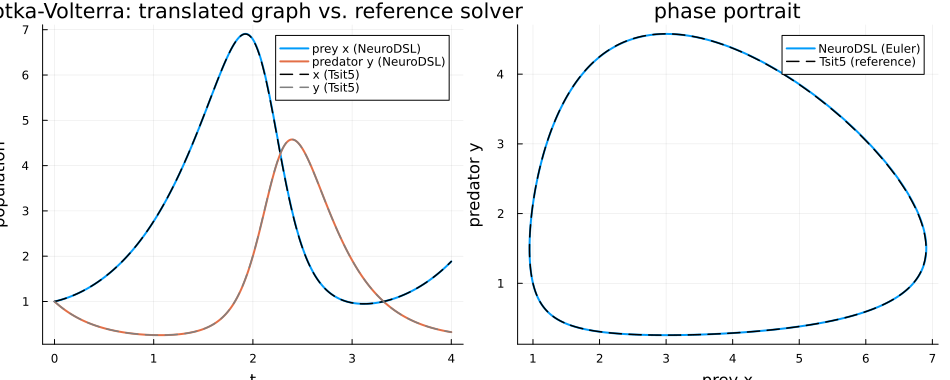

In [5]:
using Plots: plot, plot!

t_axis = dt_lv .* (0:N_STEPS_LV)
xs = Float32[1.0f0; [Array(demand!(g_lv, s))[1] for s in history_lv[:x]]]
ys = Float32[1.0f0; [Array(demand!(g_lv, s))[1] for s in history_lv[:y]]]
sol_dense = sol(t_axis)

p1 = plot(t_axis, xs; label="prey x (NeuroDSL)", lw=2, xlabel="t", ylabel="population",
          title="Lotka-Volterra: translated graph vs. reference solver")
plot!(p1, t_axis, ys; label="predator y (NeuroDSL)", lw=2)
plot!(p1, t_axis, [u[2] for u in sol_dense.u]; label="x (Tsit5)", ls=:dash, lw=1.5, color=:black)
plot!(p1, t_axis, [u[1] for u in sol_dense.u]; label="y (Tsit5)", ls=:dash, lw=1.5, color=:gray)

p2 = plot(xs, ys; label="NeuroDSL (Euler)", lw=2, xlabel="prey x", ylabel="predator y", title="phase portrait")
plot!(p2, [u[2] for u in sol_dense.u], [u[1] for u in sol_dense.u]; label="Tsit5 (reference)", ls=:dash, lw=1.5, color=:black)

plot(p1, p2; layout=(1,2), size=(950,380))

**Result:** ~0.06% relative error on both populations at t=4 (dt=0.001 forward Euler vs. `Tsit5` at `abstol=reltol=1e-10`) -- close to what forward Euler at that step size should give on a mildly stiff-looking oscillator, and independently confirmed against a real solver rather than a hand-built reference. Same translator code as section 2-3, no changes, run on a system with a genuine nonlinear coupling term it had never seen.